In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn import metrics

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "adult.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/adult-census-income",
  file_path,
)
# carrega os dados de um dataset onde será previsto se a renda é menor ou igual a 50 mil ou maior que 50 mil

/tmp/ipykernel_336555/13634615.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df.head()
# mostra as 5 primeiras linhas

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df = df.replace("?", np.nan)
# o dataset vem com ? em registros Nan entao faço uma subistituição para NaN

In [5]:
df.isnull().sum()
# quantidade de valores nulos

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [6]:
df = df.dropna()
# retiro as linhas com registros faltantes

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 1 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education.num   30162 non-null  int64 
 5   marital.status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital.gain    30162 non-null  int64 
 11  capital.loss    30162 non-null  int64 
 12  hours.per.week  30162 non-null  int64 
 13  native.country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
# a variavel alvo(income) vem como <= ou > nisso faço uma replicação para valores maiores que 50 mil sao rotulados como 1 e menosres ou iguais como 0
df["income"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0)
# para cada valor sera aplicado uma função lambda que rotula os valores

In [9]:
df["income"].value_counts()
# quantdade de valores presentes em cada classe no target

income
0    22654
1     7508
Name: count, dtype: int64

In [10]:
target = "income"
# define a coluna alvo
cat_cols = df.select_dtypes(include="object").columns.tolist()
# colunas categoricas transformadas em listas para relizar o encoding
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)
    # removendo a colunna target do resto dos dados

print("cols categoricas", cat_cols)
print("cols numericas", num_cols)

cols categoricas ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
cols numericas ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


In [11]:
le = LabelEncoder()
# instancia o objeto encoder
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    # para cada coluna na lista aplica o encoding

x = df.drop(columns=[target])
# remove a coluna target e atribui a variavel as features
y = df[target]
# y e nosso target

In [12]:
x_train,x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)
# fazemos a separação dos dados, 70% para treino e 30% para teste, o atr stratify garante que a separação nao seja desbalanceada
x_train.shape, x_test.shape
# tamanho do treino e teste

((21113, 14), (9049, 14))

In [13]:
scaler = StandardScaler()
# instancia o normalizador para colocar as colunas categoricas na mesma escala

x_train_scaled = x_train.copy()
# faz uma copia de cada base 
x_test_scaled = x_test.copy()

In [14]:
x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
# aplica o normalizador
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

In [15]:
model1 = LogisticRegression(max_iter=1000)
# atribui o modelo de regressao logistica

In [16]:
model1.fit(x_train_scaled, y_train)
# treino do modelo 

LogisticRegression(max_iter=1000)

In [17]:
y_train_prob = model1.predict_proba(x_train_scaled)[:, 1]
# pega a probabilidade do treino, pegando somente os dados da segunda classe nesse caso a maior que 50 mil
y_test_prob = model1.predict_proba(x_test_scaled)[:, 1]
# pegando a prob nos dados de teste

In [18]:
auc_train = metrics.roc_auc_score(y_train, y_train_prob)
# calculando a curva ROC para ver como o modelo foi para as duas classes
auc_test = metrics.roc_auc_score(y_test, y_test_prob)

In [19]:
print(f"AUC treino: {auc_train:.2f}")
# printa a area abaixo da linha ROC que sera usada no grafico
print(f"AUC teste: {auc_test:.2f}")

AUC treino: 0.85
AUC teste: 0.85


In [20]:
model2 = RandomForestClassifier(
    n_estimators=350, min_samples_leaf=150, n_jobs=-1, random_state=42
)
model2.fit(x_train, y_train) 
# treina o modelo com os dados nao normalizados

RandomForestClassifier(min_samples_leaf=150, n_estimators=350, n_jobs=-1,
                       random_state=42)

In [21]:
y_train_prob_model2 = model2.predict_proba(x_train)[:, 1]
# probabilidade com o modelo random forest
y_test_prob_model2 = model2.predict_proba(x_test)[:, 1]

In [22]:
auc_train_model2 = metrics.roc_auc_score(y_train, y_train_prob_model2)
# AUC para o modelo random forest
auc_test_model2 = metrics.roc_auc_score(y_test, y_test_prob_model2)

In [23]:
print(f"AUC treino: {auc_train_model2:.2f}")
print(f"AUC teste: {auc_test_model2:.2f}")

AUC treino: 0.91
AUC teste: 0.90


In [24]:
model3 = XGBClassifier(
    n_estimators=350, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42, eval_metric='logloss'
)
model3.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=-1,
              num_parallel_tree=None, ...)

In [25]:
y_train_prob_model3 = model3.predict_proba(x_train)[:, 1]
y_test_prob_model3 = model3.predict_proba(x_test)[:, 1]

In [26]:
auc_train_model3 = metrics.roc_auc_score(y_train, y_train_prob_model3)
auc_test_model3 = metrics.roc_auc_score(y_test, y_test_prob_model3)

In [27]:
print(f"AUC treino: {auc_train_model3:.2f}")
print(f"AUC teste: {auc_test_model3:.2f}")

AUC treino: 0.97
AUC teste: 0.93


In [ ]:
fpr_train_lr, tpr_train_lr, _ = metrics.roc_curve(y_train, y_train_prob)
# pegando a curva ROC para os dados de treino e teste de cad modelo
fpr_test_lr, tpr_test_lr, _ = metrics.roc_curve(y_test, y_test_prob)
fpr_train_rf, tpr_train_rf, _ = metrics.roc_curve(y_train, y_train_prob_model2)
fpr_test_rf, tpr_test_rf, _ = metrics.roc_curve(y_test, y_test_prob_model2)
fpr_train_xgb, tpr_train_xgb, _ = metrics.roc_curve(y_train, y_train_prob_model3)
fpr_test_xgb, tpr_test_xgb, _ = metrics.roc_curve(y_test, y_test_prob_model3)

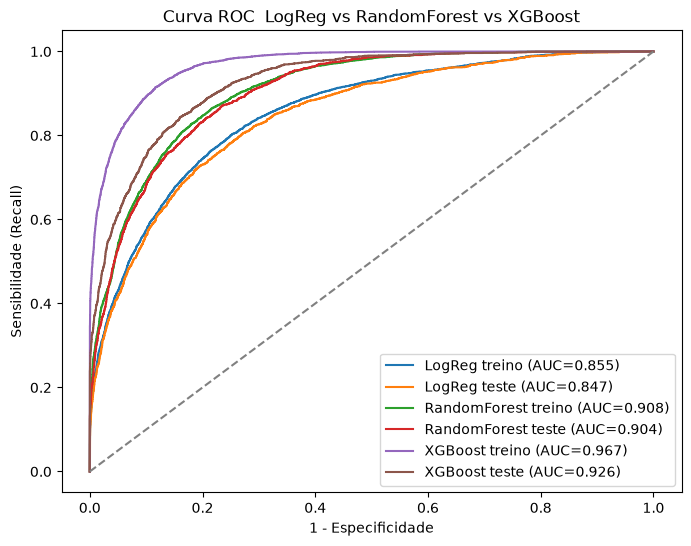

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_train_lr, tpr_train_lr, label=f"LogReg treino (AUC={auc_train:.3f})")
plt.plot(fpr_test_lr, tpr_test_lr, label=f"LogReg teste (AUC={auc_test:.3f})")
plt.plot(fpr_train_rf, tpr_train_rf, label=f"RandomForest treino (AUC={auc_train_model2:.3f})")
plt.plot(fpr_test_rf, tpr_test_rf, label=f"RandomForest teste (AUC={auc_test_model2:.3f})")
plt.plot(fpr_train_xgb, tpr_train_xgb, label=f"XGBoost treino (AUC={auc_train_model3:.3f})")
plt.plot(fpr_test_xgb, tpr_test_xgb, label=f"XGBoost teste (AUC={auc_test_model3:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade (Recall)")
plt.title("Curva ROC  LogReg vs RandomForest vs XGBoost")
plt.legend()
plt.show()

In [30]:
import os

# calcula as acuracias usando o cutoff escolhido
cutoff = 0.7
y_train_pred_model2 = (y_train_prob_model2 >= cutoff).astype(int)
# para cada predicao do modelo verifica que se a prob e maior que o cutoff e transforma em inteiro para converter para a classe
y_test_pred_model2 = (y_test_prob_model2 >= cutoff).astype(int)

acc_train = metrics.accuracy_score(y_train, y_train_pred_model2)
acc_test = metrics.accuracy_score(y_test, y_test_pred_model2)

# monta o pacote do modelo pra salvar
model_data = pd.Series({
    'num_features': num_cols,
    'cat_features': cat_cols,
    'label_encoder': le,
    'features_fit': x_train.columns.tolist(),
    'model': model2,
    'acc_train': acc_train,
    'acc_test': acc_test,
    'cutoff': cutoff
})

# salva o modelo em .pkl
model_data.to_pickle(os.path.join("/home/beuren/Documentos/Bootcamp-LAMIA/card-26", 'random_forest.pkl'))